### Sturm-Liouville Eigenvalue Problem: Shooting Method Solution

The Sturm-Liouville eigenvalue problem is, in 1D:

$$
    f''(x) + \left[ k - V(x) \right] f(x) = 0
$$

With boundary conditions:

$$
    f(0) = f(L) = 0
$$

And $f(x)$ must be normalized for $x \in [0, L]$:

$$
    \int _{0} ^ {L} \left| f(x) \right| ^ 2 \, dx = 1
$$

The shooting method transforms this boundary value problem into an initial value problem:
1. Fix $f(x = 0) = 0$ and choose $f'(x = 0) = 1$ (the magnitude doesn't matter due to linearity)
2. Solve the ODE for different trial eigenvalues $k$
3. Find $k$ values where $f(L) = 0$ (satisfying the right boundary condition)
4. These $k$ values are the eigenvalues, and their corresponding solutions are eigenfunctions

In [1]:
import numpy as np

from scipy.integrate import solve_ivp # Solves ODEs
from scipy.interpolate import make_smoothing_spline # Interpolation method
from scipy.optimize import brentq # Finds the roots of a function

import matplotlib.pyplot as plt
plt.style.use("ggplot") # Plotting style

In [2]:
def ode(x, y, k): # Defining the ODE as a system
    
    global V # Potential source as a global function

    dSdx = np.zeros(2)
    dSdx[0] = y[1]  # f' = df/dx
    dSdx[1] = (V(x) - k) * y[0]  # f'' = (V - k)f

    return dSdx

def solve_for_k(k_value, last_element = True): # Solves the ODE for a given k value

    global L # L as a global constant

    y0 = [0.0, 1.0] # Initial conditions: f(0) = 0, f'(0) = 1
    
    # Solves the ODE for x in [0, L] with initial condition f(0) = 0 and f'(0) = 1
    sol = solve_ivp(
        fun = lambda x, y: ode(x, y, k_value),
        t_span = [0, L],
        y0 = y0,
        t_eval = np.linspace(0, L, 100) if last_element is False else None # For the full solution solely
        )
    
    if last_element: # Return f(L) if last_element is True
        return sol.y[0, -1]
    else: # Or return the full solution normalized
        x, y = (sol.t, sol.y[0, :])
        
        N = np.trapezoid(y ** 2, x)

        return (x, y / np.sqrt(N))

def shooting_method_scan(k_min, k_max, n_points, monitor = 100): # Shooting method to find k vs f(L) 

    global L
    
    k_values = np.linspace(k_min, k_max, n_points)
    f_values = np.zeros_like(k_values)
    
    print("Scanning k values...") # Solve ODE for each k

    for i, k in enumerate(k_values):
        f_values[i] = solve_for_k(k)
        
        if i % monitor == 0: # Monitor feature
            print(f"k = {k:.2f}, f(L) = {f_values[i]:.4e}")

    return (k_values, f_values)

def plot_shooter(k_values, f_values, x_ticks = None):

    plt.figure(figsize = (10, 5))
    plt.plot(k_values, f_values, 'k-', linewidth = 1.5)
    plt.axhline(y = 0, color = 'r', linestyle = '--', alpha = 0.5)
    plt.xlabel('k')
    if x_ticks is not None: plt.xticks(x_ticks) # To adjust xticks if we need it
    plt.ylabel('f(L)')
    plt.title('Shooting Method: f(L) vs k')
    plt.grid(True, alpha = 0.5)
    plt.show()

    return None

def plot_eigs(r_list):
    plt.figure(figsize = (10, 5))
    
    for r in r_list: # Plotting the eigenfunctions
        x, y = solve_for_k(r, last_element = False)
        plt.plot(x, y, label = f'k = {r:.2f}', linewidth = 1.5)

    plt.title(f"First {len(r_list)} Eigenfunction(s)")
    plt.legend(bbox_to_anchor = (1, 1))
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid(True, alpha = 0.5)
    plt.show()

Scanning k values...
k = -50.00, f(L) = 8.8741e+04
k = -34.98, f(L) = 1.0335e+04
k = -19.97, f(L) = 7.3625e+02
k = -4.95, f(L) = 1.5089e+01
k = 10.06, f(L) = 8.3751e-02
k = 25.08, f(L) = -1.3133e-01
k = 40.09, f(L) = 3.4280e-02
k = 55.11, f(L) = 9.0635e-02
k = 70.12, f(L) = -1.0716e-01
k = 85.14, f(L) = -3.2220e-02


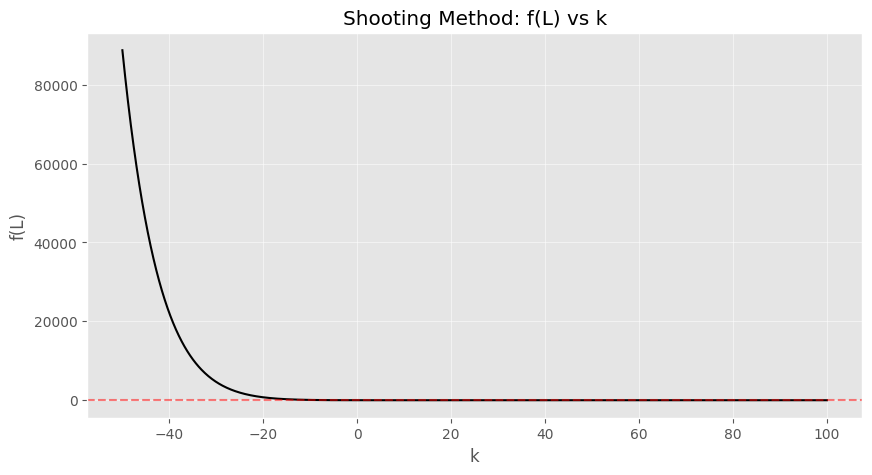

In [3]:
# Globals
L = 2
V = lambda x: - x ** 4 / 4 + x ** 3 / 3 - x ** 2 / 2 + x - 1 # Can be anything

k, f = shooting_method_scan( # Shooting algorithm running
    k_min = - 50,
    k_max = 100,
    n_points = 1_000
)

plot_shooter(k, f) # Plotting k vs f(L)

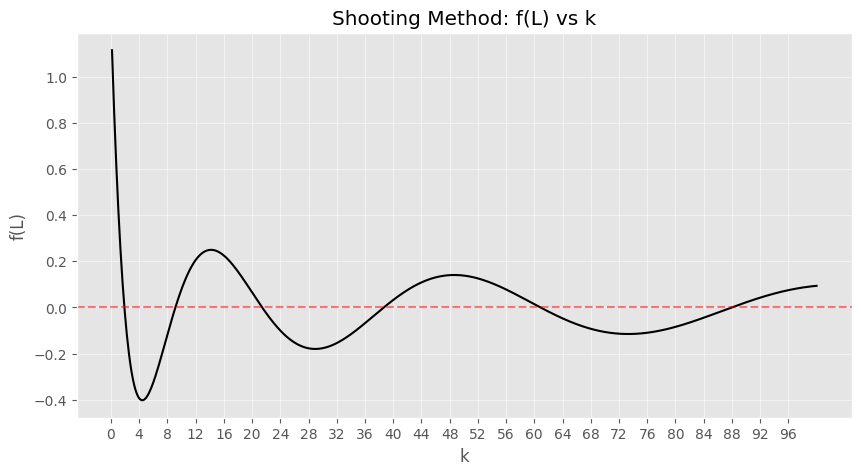

In [4]:
# Mask: only positive ks are relevant
mask = (k > 0)
k, f = k[mask], f[mask]

plot_shooter(k, f, x_ticks = np.arange(0, max(k), 4)) # Adjusting the xticks to easily find the roots

1.906616690995961 9.134678636268966 21.427684529044264 38.67552800656004 60.86249452662029 87.9843857352369


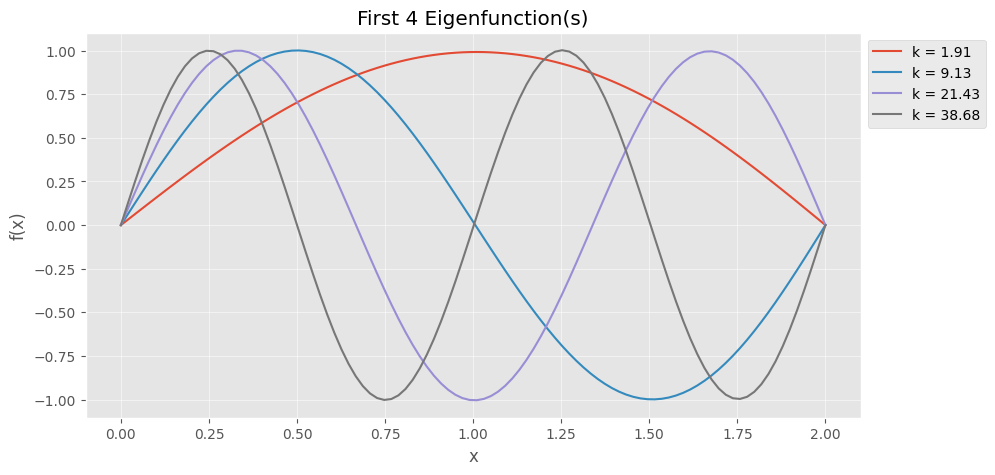

In [5]:
F = make_smoothing_spline(k, f) # Fast interpolation for brentq()

# List of roots (eigenvalues)
r_list = [
    brentq(F, 0, 4),
    brentq(F, 8, 12),
    brentq(F, 20, 24),
    brentq(F, 36, 40),
    brentq(F, 60, 64),
    brentq(F, 84, 88)
]

print(*r_list)
plot_eigs(r_list[0:4]) # Plot first 4 eigenfunctions

Scanning k values...
k = -100.00, f(L) = 8.3237e+01
k = -89.99, f(L) = 4.4089e+01
k = -79.98, f(L) = 2.1799e+01
k = -69.97, f(L) = 9.7608e+00
k = -59.96, f(L) = 3.7126e+00
k = -49.95, f(L) = 9.9168e-01
k = -39.94, f(L) = -9.7118e-03
k = -29.93, f(L) = -2.1726e-01
k = -19.92, f(L) = -1.3043e-01
k = -9.91, f(L) = 7.9034e-03


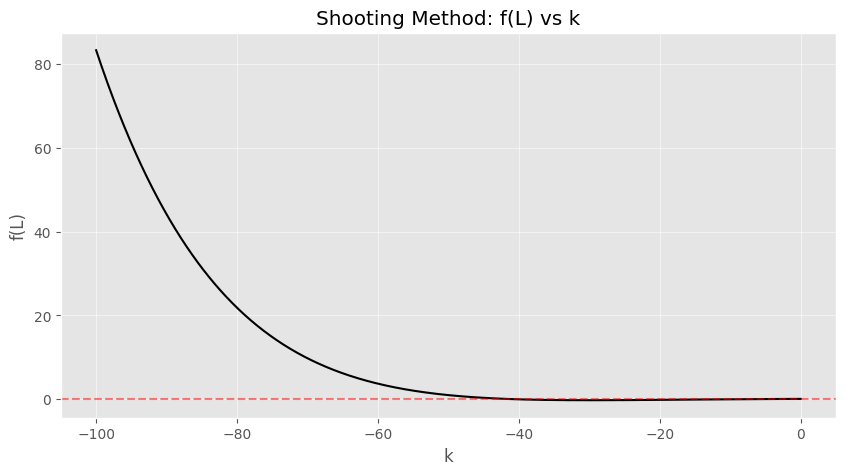

In [6]:
L = 1
V = lambda _: - 50 # Constant scenario

k, f = shooting_method_scan( # Shooting algorithm running
    k_min = - 100,
    k_max = 0, # Searching only negative eigenvalues
    n_points = 1_000
)

plot_shooter(k, f) # Plotting k vs f(L)

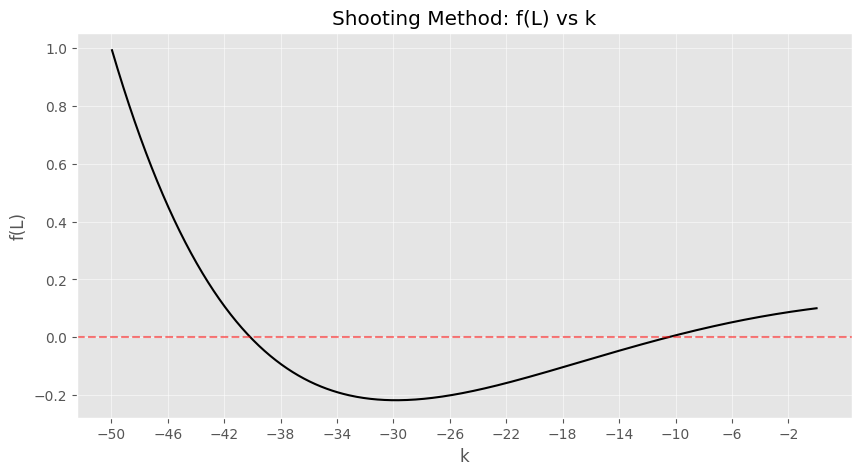

In [7]:
mask = (k > - 50)
k, f = k[mask], f[mask]

plot_shooter(k, f, x_ticks = np.arange(- 50, max(k), 4))

-40.13441379293858 -10.540936939689827


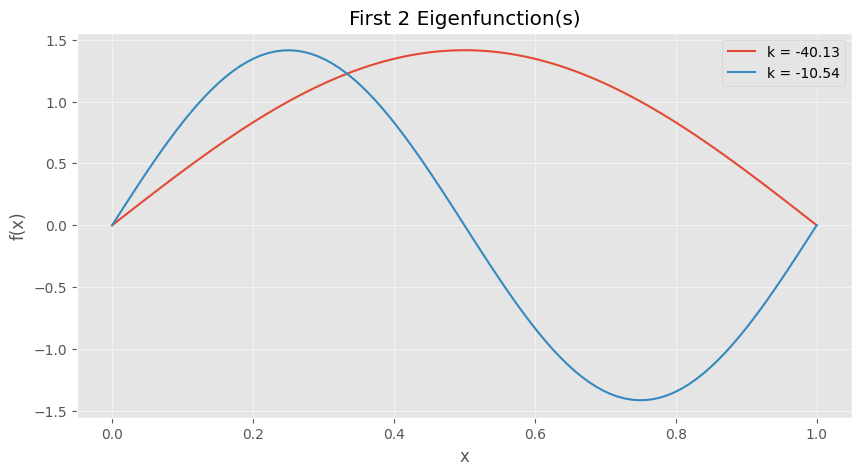

In [8]:
F = make_smoothing_spline(k, f) # Fast interpolation for brentq()

# Only two negative eigenvalues found
r_list = [
    brentq(F, - 42, - 38),
    brentq(F, - 14, - 10)
]

print(*r_list)
plot_eigs(r_list)